<a href="https://colab.research.google.com/github/sahil-walunj/Formal_verification_of_Deep_Neural_Networks/blob/main/CNN_MILP_VGG16_strided_conv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gurobipy
!pip install tensorflow
!pip install numpy
!pip install matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Flatten, Dense,MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [ ]:
# params = {
#     "WLSACCESSID":"4d102d43-af47-4767-8294-5c56341d0f8a",
#     "WLSSECRET":"dae74acb-a20b-4fec-92b6-9737c8626ca6",
#     "LICENSEID":2778199
# }
# env = gp.Env(params=params)

In [ ]:
print("--- 1. Loading and Preprocessing MNIST Data ---")
(x_train, y_train), (x_test, y_test) = mnist.load_data()



# Normalize and add channel dimension (for CNN)
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)


x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Save original labels
y_test_orig = y_test

# Convert labels to one-hot encoding for training
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

--- 1. Loading and Preprocessing MNIST Data ---
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [ ]:
N_LAYERS = 2
print(f"Model will be built with N={N_LAYERS} convolutional layers.")

Model will be built with N=2 convolutional layers.


In [ ]:
def model_archi_cnn(num_conv_layers):

    inp = Input(shape=(28, 28, 1), name="input")
    x = inp # Initialize x with the input

    # --- Loop to create N CNN Blocks ---
    for i in range(1, num_conv_layers + 1):
        filters = 4 * (2 ** (i-1))   # 4 → 8 → 16
        x = Conv2D(filters, (3, 3), padding='same', name=f"conv{i}_1")(x)
        x = Activation('relu')(x)

        x = Conv2D(filters, (3, 3), padding='same', strides=(2,2), name=f"conv{i}_2")(x)
        x = Activation('relu')(x)


    # Flatten the output of the last conv block
    x = Flatten(name="flatten")(x)

    # Output layer
    # x = Dense(256, activation='relu', name="fc1")(x)  #we remove this layer because this layer itself adds ~100K params
    outputs = Dense(10,activation='softmax',name="output_layer")(x)

    return Model(inputs=inp, outputs=outputs)


model_cnn = model_archi_cnn(num_conv_layers=N_LAYERS)


model_cnn.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 28, 28, 4)         40        
                                                                 
 activation (Activation)     (None, 28, 28, 4)         0         
                                                                 
 conv1_2 (Conv2D)            (None, 14, 14, 4)         148       
                                                                 
 activation_1 (Activation)   (None, 14, 14, 4)         0         
                                                                 
 conv2_1 (Conv2D)            (None, 14, 14, 8)         296       
                                                                 
 activation_2 (Activation)   (None, 14, 14, 8)         0    

In [ ]:
print("\n--- 2. Compiling CNN Model ---")

# Use a standard, safe learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_cnn.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=optimizer,
    metrics=['accuracy']
)
print("\nModel compiled successfully.")


--- 2. Compiling CNN Model ---

Model compiled successfully.


In [ ]:
print("\n--- 3. Training CNN Model ---")

history = model_cnn.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test)
)

print("\nTraining complete.")


--- 3. Training CNN Model ---
Epoch 1/10


469/469 [==============================] - 3s 4ms/step - loss: 0.4756 - accuracy: 0.8514 - val_loss: 0.1971 - val_accuracy: 0.9395
Epoch 2/10
469/469 [==============================] - 2s 3ms/step - loss: 0.1644 - accuracy: 0.9503 - val_loss: 0.1339 - val_accuracy: 0.9603
Epoch 3/10
469/469 [==============================] - 1s 3ms/step - loss: 0.1241 - accuracy: 0.9627 - val_loss: 0.1179 - val_accuracy: 0.9636
Epoch 4/10
469/469 [==============================] - 2s 4ms/step - loss: 0.1054 - accuracy: 0.9675 - val_loss: 0.0955 - val_accuracy: 0.9703
Epoch 5/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0930 - accuracy: 0.9722 - val_loss: 0.0875 - val_accuracy: 0.9730
Epoch 6/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0844 - accuracy: 0.9742 - val_loss: 0.0888 - val_accuracy: 0.9728
Epoch 7/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0776 - accuracy: 0.9764 - val_loss: 0.0

In [ ]:
test_loss, test_acc = model_cnn.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0661 - accuracy: 0.9793
Test Loss: 0.06611142307519913
Test Accuracy: 0.9793000221252441


In [ ]:
print(f"\n--- 4. Saving CNN Weights for {N_LAYERS} Layers to cnn_net/ ---")
os.makedirs("cnn_net", exist_ok=True)


def get_layer(name):
    return model_cnn.get_layer(name)

# save weights for N layers
for i in range(1, N_LAYERS + 1):
    conv_1_name = f"conv{i}_1"
    conv_2_name = f"conv{i}_2"

    print(f"Saving weights for {conv_1_name} and {conv_2_name}...")
    # print(get_layer(conv_1_name).get_weights()[0])
    # print(get_layer(conv_2_name).get_weights()[1])

    # Save Conv{i}
    np.save(f"cnn_net/{conv_1_name}.weight", get_layer(conv_1_name).get_weights()[0]) # Kernel
    np.save(f"cnn_net/{conv_1_name}.bias",   get_layer(conv_1_name).get_weights()[1]) # Bias

    # Save BN{i}
    np.save(f"cnn_net/{conv_2_name}.weight",   get_layer(conv_2_name).get_weights()[0]) #Kernel
    np.save(f"cnn_net/{conv_2_name}.bias",     get_layer(conv_2_name).get_weights()[1]) #bias


# Save Output Layer
np.save("cnn_net/output_layer.weight", get_layer("output_layer").get_weights()[0])
np.save("cnn_net/output_layer.bias",   get_layer("output_layer").get_weights()[1])
print(get_layer("output_layer").get_weights()[0].shape)
print(get_layer("output_layer").get_weights()[1].shape)

print("All weights saved.")


--- 4. Saving CNN Weights for 2 Layers to cnn_net/ ---
Saving weights for conv1_1 and conv1_2...
Saving weights for conv2_1 and conv2_2...
(392, 10)
(10,)
All weights saved.


In [ ]:
# print("\n--- 5. Setting up Gurobi Environment and Helpers ---")

# env.setParam('OutputFlag', 0)   # avoids unnecessary outputs
def load_weight_cnn(name):
    return np.load(os.path.join("cnn_net", name + ".npy"))

cutout_size=6

In [ ]:
# @title
# =============================================================================
# PART 3 & 4: PERTURBATION GENERATION & FILTERING
# =============================================================================

def generate_failures(model, x_test, y_test, cutout_size, max_scan_images=2000):
    print(f"\n--- 3. Scanning {max_scan_images} images for failures ---")

    failures = []
    preds_orig = np.argmax(model.predict(x_test[:max_scan_images], verbose=0), axis=1)

    center_x, center_y = 14, 14
    half_size = cutout_size // 2
    start_x, start_y = center_x - half_size, center_y - half_size

    x_perturbed_batch = x_test[:max_scan_images].copy()
    x_perturbed_batch[:, start_x:start_x+cutout_size, start_y:start_y+cutout_size, :] = 0.0

    preds_pert = np.argmax(model.predict(x_perturbed_batch, verbose=0), axis=1)

    for idx in range(max_scan_images):
        yi = np.argmax(y_test[idx])
        if preds_orig[idx] == yi and preds_pert[idx] != yi:
            failures.append({
                'id': idx,
                'original': x_test[idx],
                'perturbed': x_perturbed_batch[idx],
                'true_label': y_test[idx],
                'wrong_label': preds_pert[idx]
            })

    print(f"Found {len(failures)} failure cases.")
    return failures

In [ ]:
failures = generate_failures(model_cnn, x_test, y_test, cutout_size, max_scan_images=500)


--- 3. Scanning 500 images for failures ---
Found 80 failure cases.


In [ ]:
# =============================================================================
# PART 5: MILP REPAIR (UNMODIFIED CONSTANTS)
# =============================================================================

def solve_tau_milp(model, failure_case, grid_size=6,tauType=0):
    x_pert = failure_case['perturbed']
    true_label = np.argmax(failure_case['true_label']) # Fix: Convert one-hot to scalar index

    # try:
    #     # Create environment
    #     env = gp.Env(empty=True)
    #     env.setParam("OutputFlag", 0)
    #     env.start()
    # except:
    #     print("Gurobi License Error or Not Found. (Ensure Gurobi is installed and licensed)")
    #     return None

    m = gp.Model("ABCNet_Repair")
    m.setParam("TimeLimit", 600)
    m.setParam("OutputFlag", 0)
    m.setParam("MIPFocus", 1)

    # --- VARIABLES ---
    x_input = m.addMVar((28, 28, 1), lb=0, ub=1, name="x_input")

    if tauType==1:
      tau = m.addMVar((grid_size, grid_size), lb=0, ub=1, name="tau")
    else:
      tau = m.addMVar((grid_size, grid_size), vtype=GRB.BINARY, name="tau")
    start = 14 - grid_size // 2

    # Input Constraint
    for r in range(28):
        for c in range(28):
            if start <= r < start + grid_size and start <= c < start + grid_size:
                tr, tc = r - start, c - start
                m.addConstr(x_input[r, c, 0] == tau[tr, tc])
            else:
                m.addConstr(x_input[r, c, 0] == x_pert[r, c, 0])

    # --- LAYER ENCODING ---
    current_vars = x_input
    layer_idx = 1 # Skip Input Layer

    # Parsing layers: ZeroPad -> ABCConv -> BN -> Act
    while layer_idx < len(model.layers):
        layer = model.layers[layer_idx]

        if isinstance(layer, tf.keras.layers.Conv2D):
            W_eff, b_conv = layer.get_weights()
            stride = layer.strides[0] # Access the first element if stride is a tuple

            # Removed: act_layer = model.layers[layer_idx+1] and betas, vs = act_layer.get_params()
            # because Activation layers do not have get_params()

            h_in, w_in, c_in = current_vars.shape

            # --- FIX STARTS HERE ---
            # Get kernel dimensions from the effective weights
            k_h, k_w, _, _ = W_eff.shape

            # Correct Convolution Arithmetic: (Input + Padding - Kernel) // Stride + 1
            # Note: We add +2 to h_in/w_in because we explicitly padded the input by 1 on both sides
            h_out = (h_in + 2 - k_h) // stride + 1
            w_out = (w_in + 2 - k_w) // stride + 1
            c_out = W_eff.shape[-1]

            # For ReLU, output is non-negative
            layer_out = m.addMVar((h_out, w_out, c_out), lb=0, ub=GRB.INFINITY) # Changed lb to 0

            # MILP Padding: 1 pixel all around (Hardcoded constraint)
            padded = m.addMVar((h_in+2, w_in+2, c_in), lb=-GRB.INFINITY)
            m.addConstr(padded[1:-1, 1:-1, :] == current_vars)
            m.addConstr(padded[0,:,:]==0); m.addConstr(padded[-1,:,:]==0)
            m.addConstr(padded[:,0,:]==0); m.addConstr(padded[:,-1,:]==0)

            for r in range(h_out):
                for c in range(w_out):
                    in_r = r * stride
                    in_c = c * stride

                    for k in range(c_out):
                        w_kernel = W_eff[:, :, :, k]

                        # Vectorized weight identification (works for 3x3, 5x5, etc.)
                        nz_idx = np.where(np.abs(w_kernel) > 1e-5)
                        nz_vals = w_kernel[nz_idx]

                        if not nz_vals.size: # All weights for this output channel are zero
                            # If all weights are zero, output is just max(0, bias)
                            m.addConstr(layer_out[r, c, k] == max(0.0, b_conv[k]))
                        else:
                            input_vars_list = padded[
                                in_r + nz_idx[0],
                                in_c + nz_idx[1],
                                nz_idx[2]
                            ].tolist()

                            conv_expr = gp.LinExpr(b_conv[k])
                            conv_expr.addTerms(nz_vals, input_vars_list)

                            # --- NEW ACTIVATION LOGIC FOR ReLU ---
                            # 1. Create a temporary variable for the convolution output before activation
                            conv_output_pre_relu = m.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY,
                                                            name=f"conv_relu_in_{r}_{c}_{k}")
                            m.addConstr(conv_output_pre_relu == conv_expr)

                            # 2. Apply ReLU activation using GenConstrMax: output = max(input, 0)
                            m.addGenConstrMax(layer_out[r, c, k],
                                              [conv_output_pre_relu, 0.0],
                                              name=f"relu_act_{r}_{c}_{k}")
                            # --- END NEW ACTIVATION LOGIC ---

            current_vars = layer_out
            layer_idx += 2 # Conv, Act

        elif isinstance(layer, tf.keras.layers.Flatten):
            layer_idx += 1

        elif isinstance(layer, tf.keras.layers.Dense):
            W, b = layer.get_weights()
            flat_in = current_vars.reshape(-1)
            # Hardcoded assumption: Dense layer is the final 10-class output
            logits = m.addMVar(10, lb=-GRB.INFINITY)

            for j in range(10):
                expr = gp.LinExpr(b[j])
                for i in range(flat_in.shape[0]):
                    expr += flat_in[i] * W[i, j]
                m.addConstr(logits[j] == expr)

            layer_idx += 1
        else:
            layer_idx += 1

    # --- OBJECTIVE ---
    target_logit = logits[true_label]
    for i in range(10):
        if i != true_label:
            m.addConstr(target_logit >= logits[i] + 1)

    m.setObjective(0, GRB.MINIMIZE)

    print(f"Solving for True Label {true_label}...")
    m.optimize()

    if m.status == GRB.OPTIMAL:
        found_tau_vals = tau.X
        print(f"Pixels to add: {np.sum(found_tau_vals)}")
        return found_tau_vals
    elif m.status == GRB.INFEASIBLE:
        print("Model is Infeasible.")
        return None
    else:
        print(f"No Repair Found (Status {m.status})")
        return None

Selecting 80 random failure cases...

--- Case 1 / 80 ---
Set parameter Username
Set parameter LicenseID to value 2794202
Academic license - for non-commercial use only - expires 2027-03-18
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 601.5972 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 2 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 2.0
Optimization Time: 2.2382 seconds


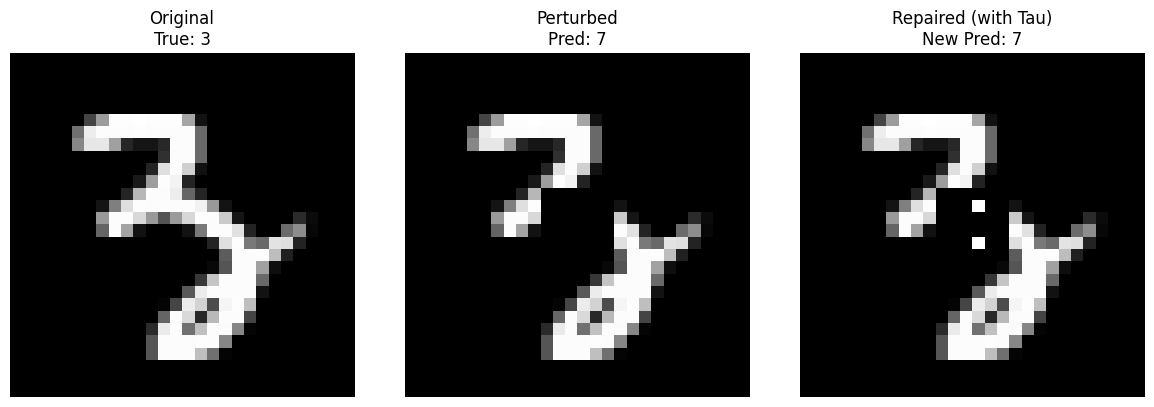


--- Case 3 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
Pixels to add: 14.0
Optimization Time: 345.0161 seconds
Successfully restored!


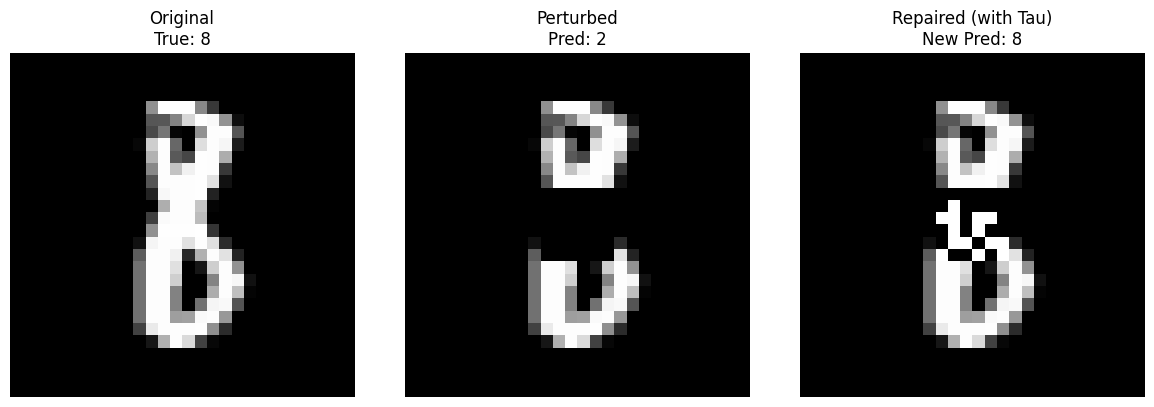


--- Case 4 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 601.6561 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 5 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 604.1054 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 6 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.4296 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 7 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 6...
No Repair Found (Status 9)
Optimization Time: 603.6085 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 8 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.2893 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 9 / 80 ---

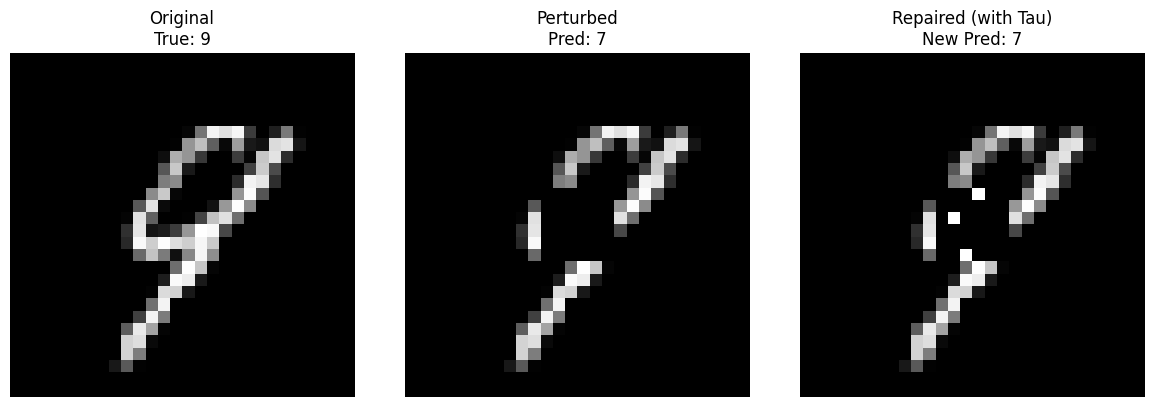


--- Case 12 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.0967 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 13 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 0.0
Optimization Time: 1.7697 seconds


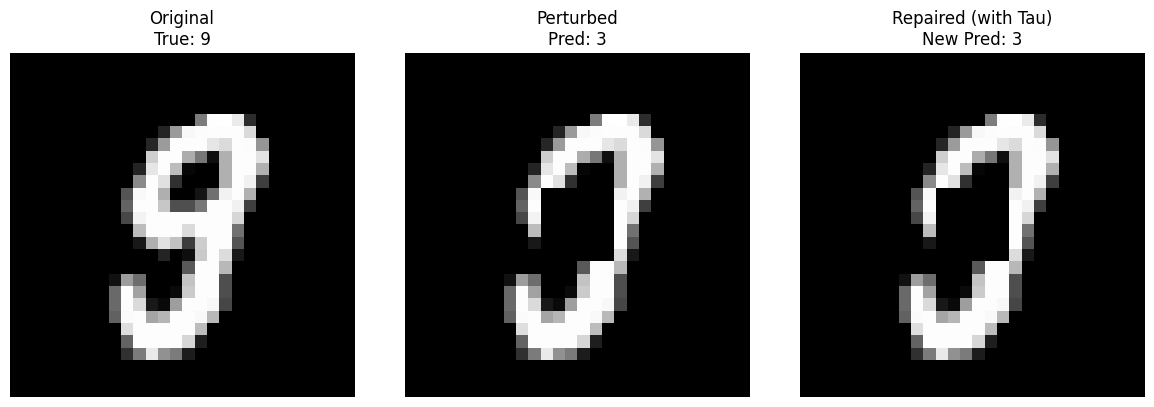


--- Case 14 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
Pixels to add: 10.0
Optimization Time: 54.6227 seconds
Successfully restored!


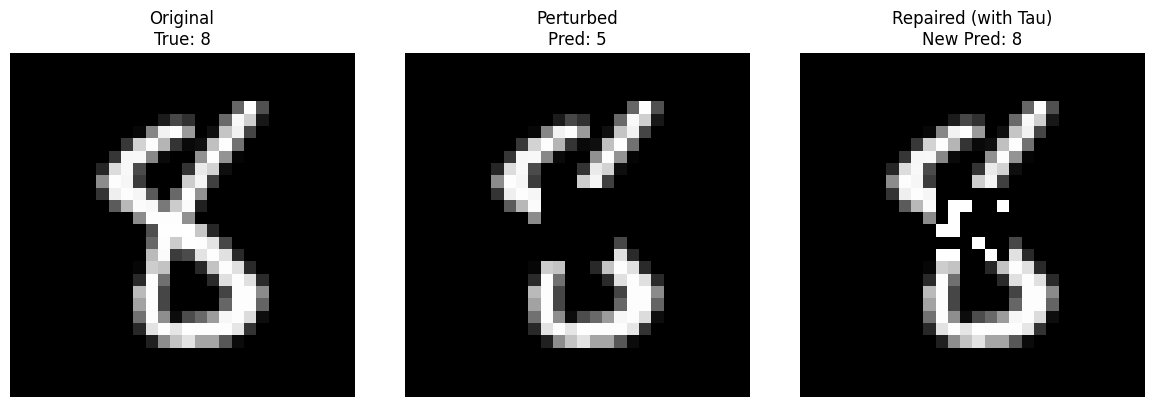


--- Case 15 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.2826 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 16 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.9553 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 17 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 602.8966 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 18 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.2630 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 19 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.6288 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 20 / 

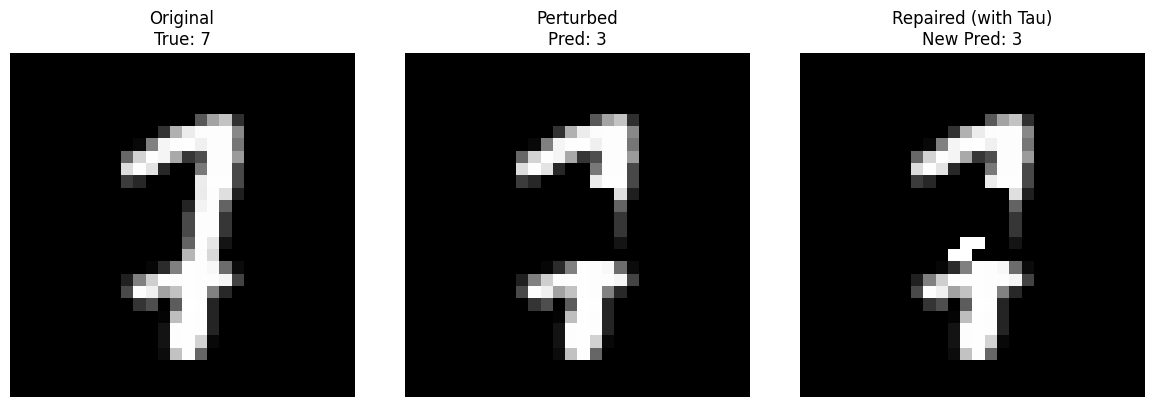


--- Case 36 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 1.7744 seconds


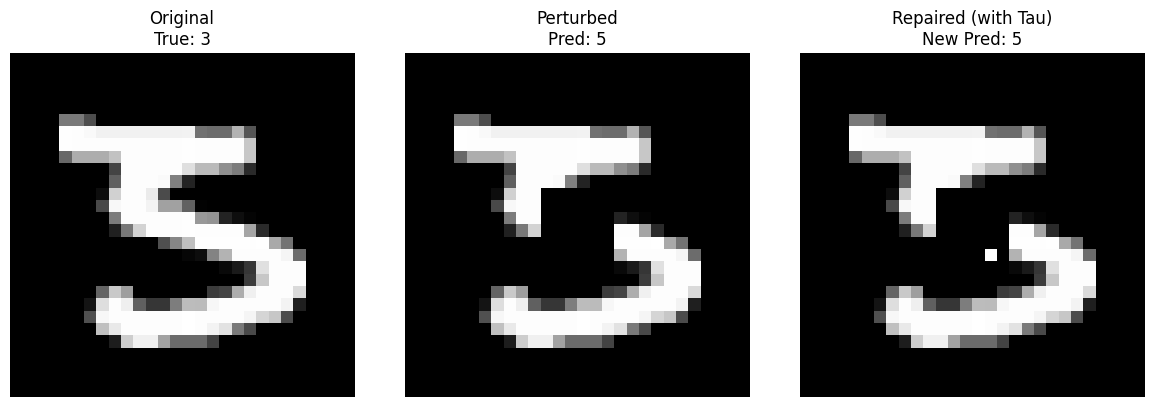


--- Case 37 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.3963 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 38 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
No Repair Found (Status 9)
Optimization Time: 601.4142 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 39 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 602.1309 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 40 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 9.0
Optimization Time: 47.0395 seconds
Successfully restored!


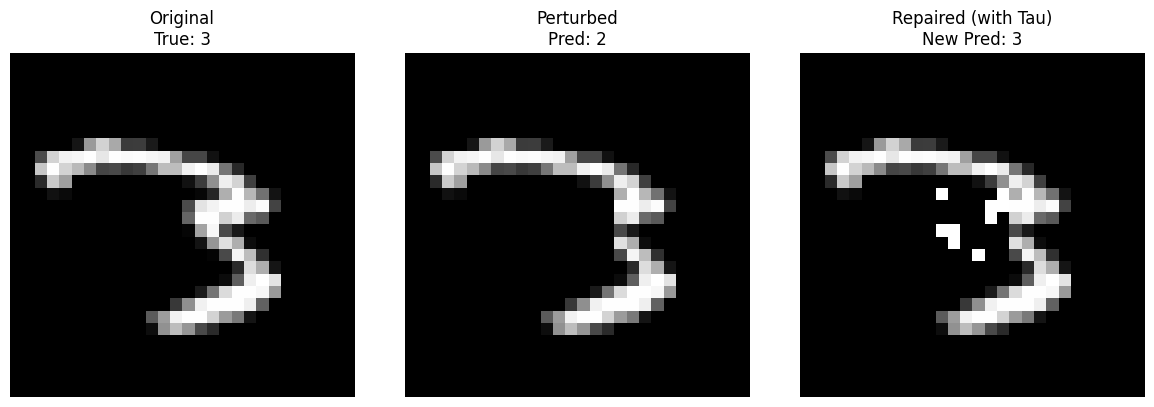


--- Case 41 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.9302 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 42 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
Pixels to add: 8.0
Optimization Time: 4.0166 seconds
Successfully restored!


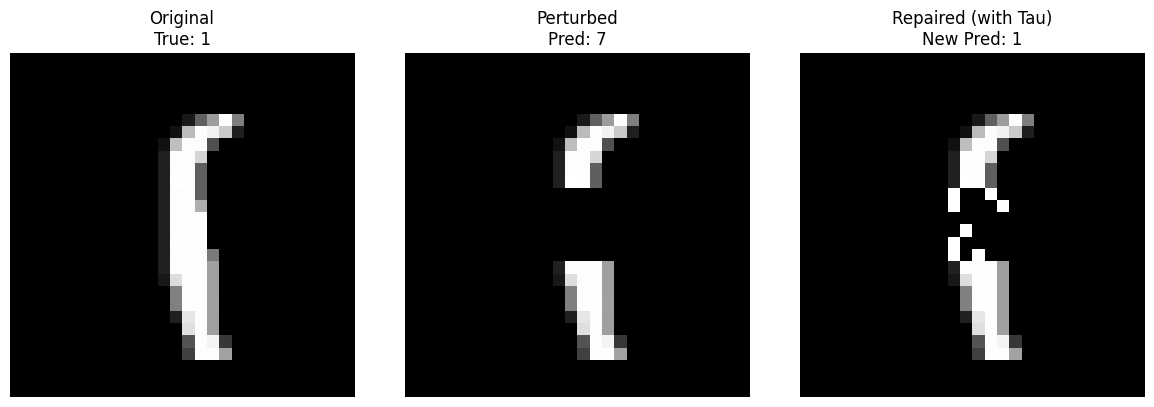


--- Case 43 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 602.9313 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 44 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.5081 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 45 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 602.0278 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 46 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.1204 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 47 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.6769 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 48 / 

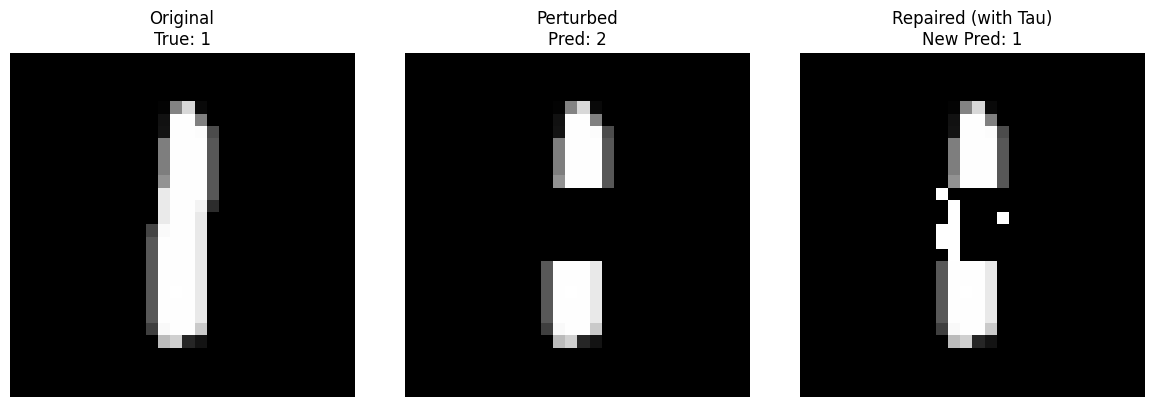


--- Case 49 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 5.0
Optimization Time: 10.4007 seconds
Successfully restored!


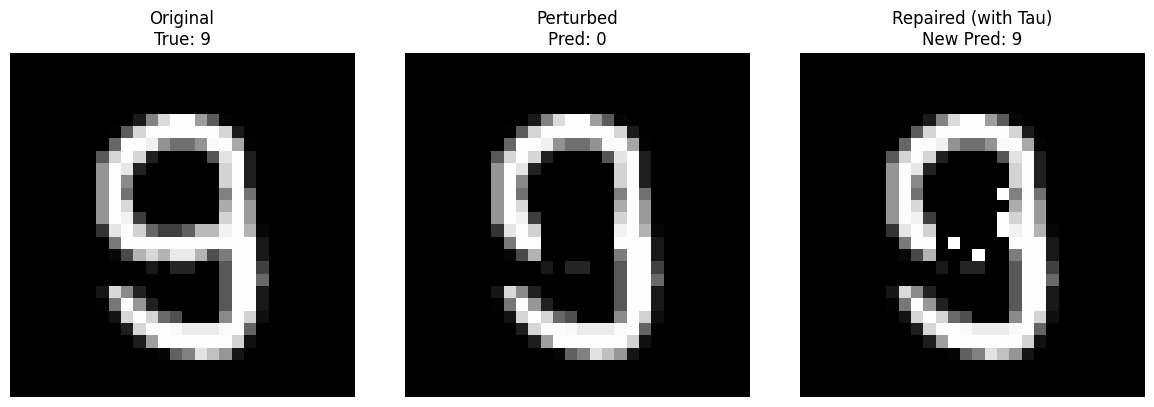


--- Case 50 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.0078 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 51 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.4729 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 52 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.4952 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 53 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 12.0
Optimization Time: 173.2366 seconds


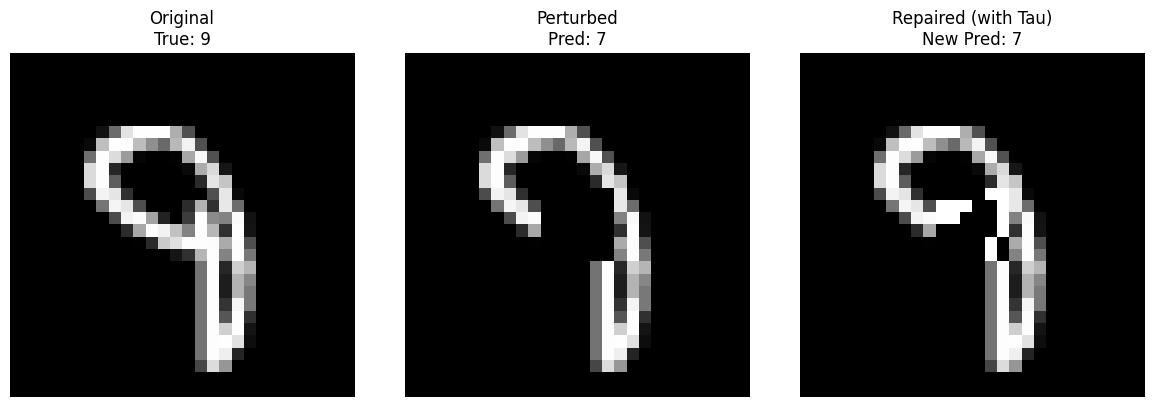


--- Case 54 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.2610 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 55 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 5.0
Optimization Time: 2.1644 seconds
Successfully restored!


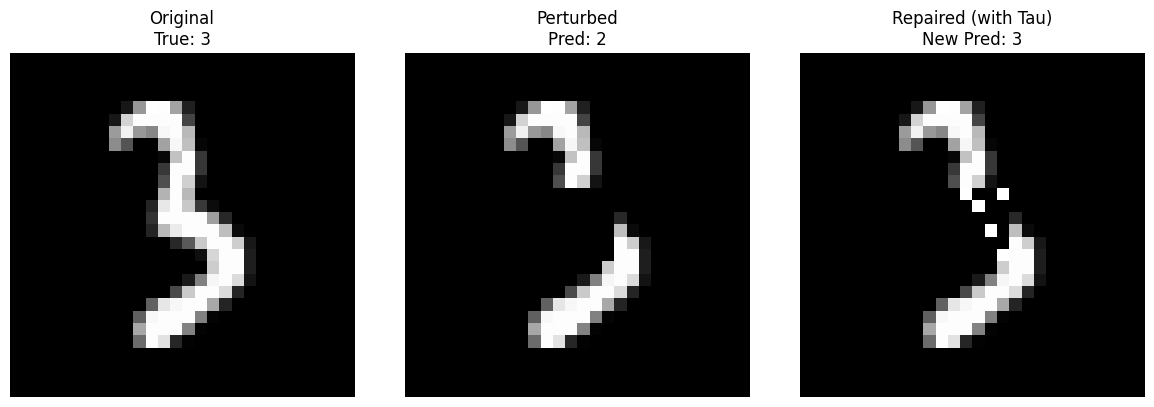


--- Case 56 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.3638 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 57 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
Pixels to add: 34.0
Optimization Time: 3.7289 seconds
Successfully restored!


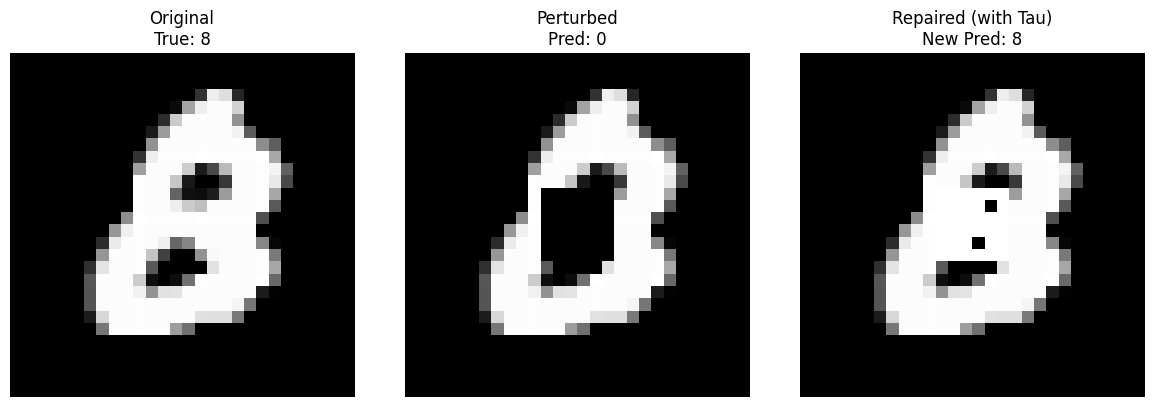


--- Case 58 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.2979 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 59 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.3420 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 60 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
Pixels to add: 21.0
Optimization Time: 585.3985 seconds
Successfully restored!


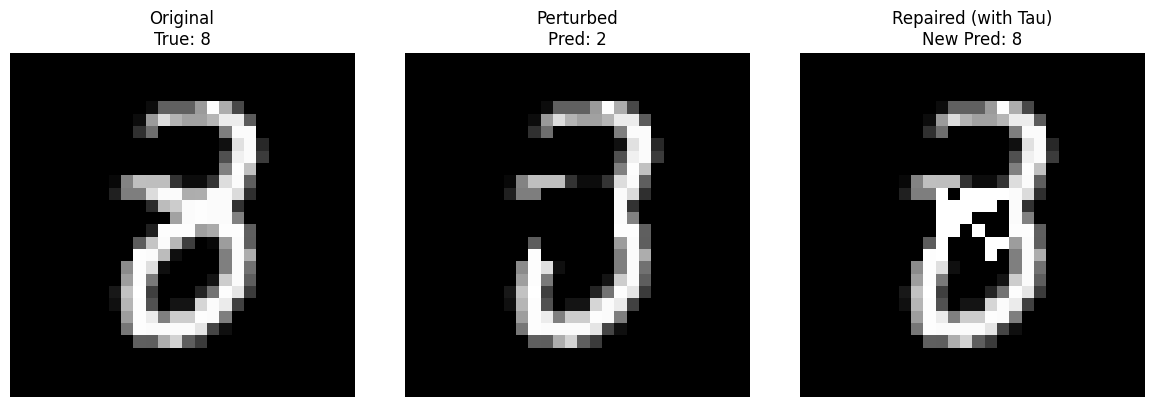


--- Case 61 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.8931 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 62 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
Pixels to add: 15.0
Optimization Time: 10.3368 seconds
Successfully restored!


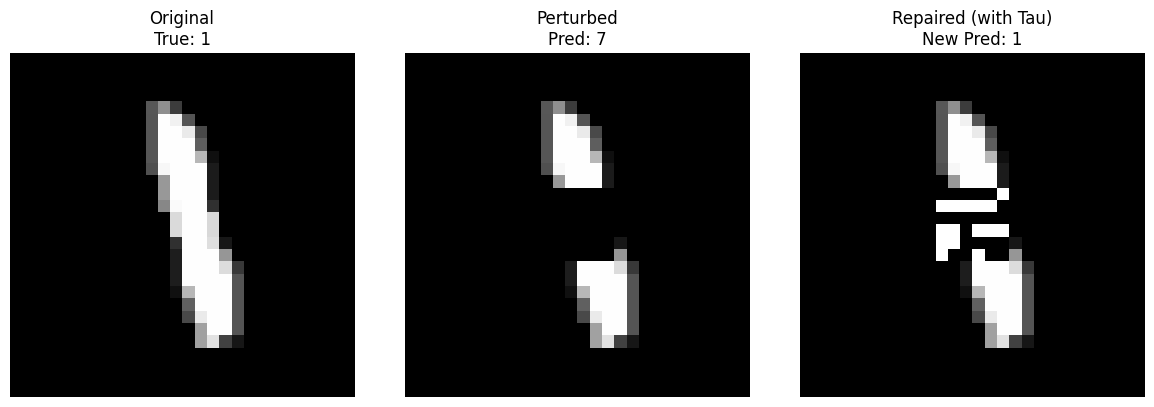


--- Case 63 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 9.0
Optimization Time: 152.1584 seconds
Successfully restored!


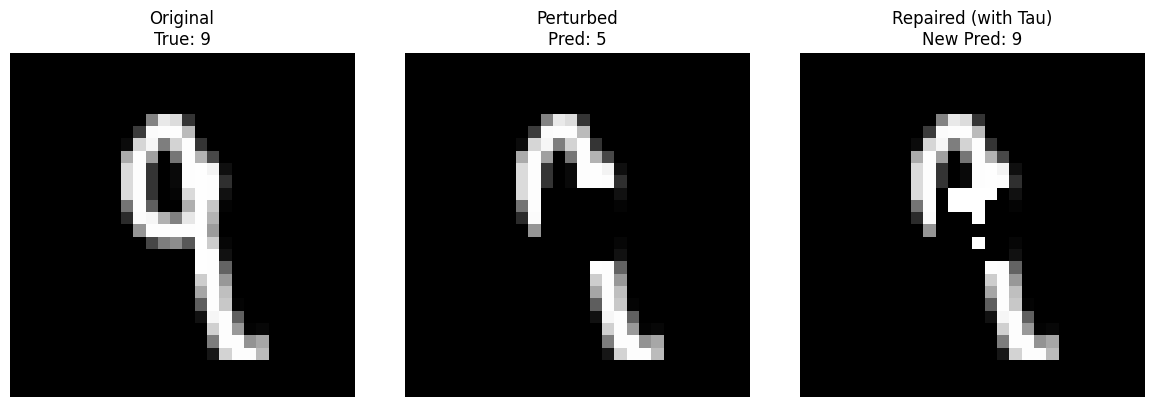


--- Case 64 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 603.0679 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 65 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.6224 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 66 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 603.9919 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 67 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 0.0
Optimization Time: 1.8275 seconds


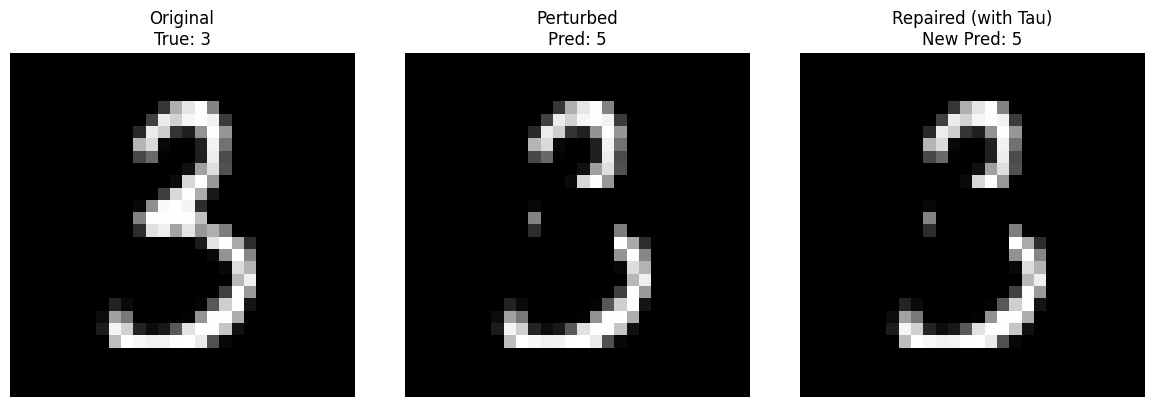


--- Case 68 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.6350 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 69 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.6901 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 70 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.3565 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 71 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 232.9372 seconds


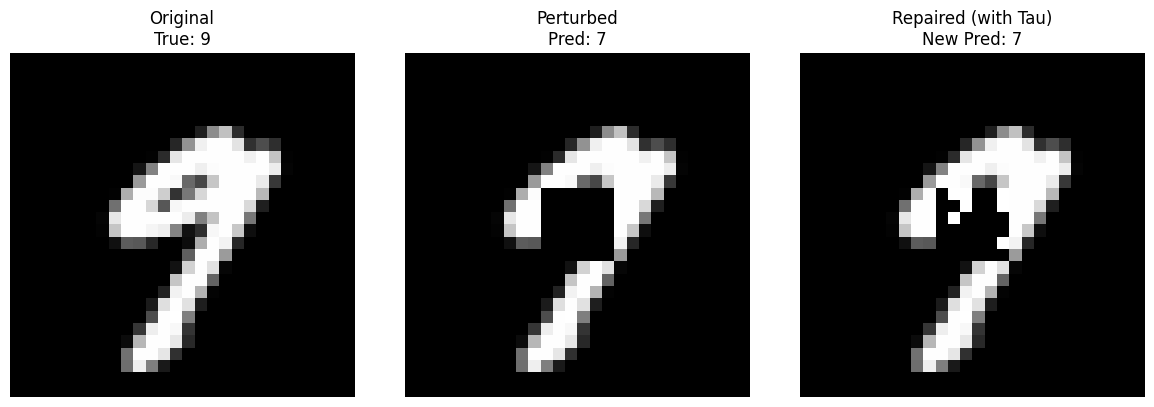


--- Case 72 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
Pixels to add: 18.0
Optimization Time: 400.2047 seconds
Successfully restored!


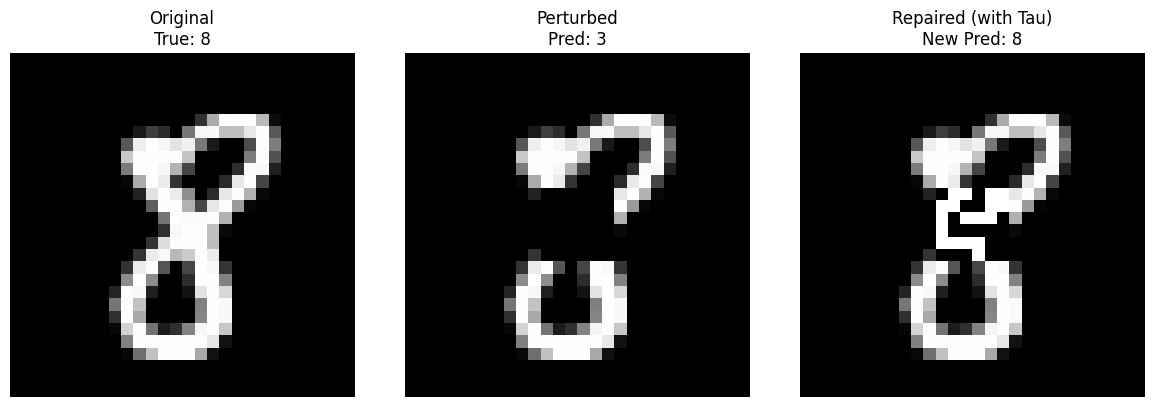


--- Case 73 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
No Repair Found (Status 9)
Optimization Time: 601.2971 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 74 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.2573 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 75 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.6984 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 76 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 6...
Model is Infeasible.
Optimization Time: 93.8222 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 77 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.8468 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 78 / 80 ---


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random  # <--- Added import

# 4. Solve & Visualize
subset = 100
grid_size = cutout_size
start_idx = 14 - grid_size // 2
correct = 0

# --- RANDOM SELECTION LOGIC ---
total_failures = len(failures)
actual_subset_size = min(subset, total_failures) # Safety check

if actual_subset_size < subset:
    print(f"Warning: Requested {subset} images, but only found {total_failures} failures.")

print(f"Selecting {actual_subset_size} random failure cases...")
selected_failures = random.sample(failures, actual_subset_size)
# ------------------------------

st_time = time.time()

# Iterate over the randomly selected list
for i, case in enumerate(selected_failures):
    print(f"\n--- Case {i+1} / {actual_subset_size} ---")

    # --- START TIMER ---
    start_time = time.time()

    # Run the solver
    tau_val = solve_tau_milp(model_cnn, case, grid_size=grid_size,tauType=0)

    # --- STOP TIMER ---
    elapsed_time = time.time() - start_time
    print(f"Optimization Time: {elapsed_time:.4f} seconds")

    if tau_val is not None:
        plt.figure(figsize=(12, 4))

        # 1. Original
        plt.subplot(1, 3, 1)
        plt.title(f"Original\nTrue: {np.argmax(case['true_label'])}")
        plt.imshow(case['original'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 2. Perturbed (Attack)
        plt.subplot(1, 3, 2)
        plt.title(f"Perturbed\nPred: {case['wrong_label']}")
        plt.imshow(case['perturbed'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 3. Apply Tau (Repair)
        repaired = case['perturbed'].copy()

        # Robust logic: Zero out the area first, then add tau
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] = 0.0
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] += tau_val

        # Verify Prediction
        pred_prob = model_cnn.predict(np.expand_dims(repaired, 0), verbose=0)
        pred_lbl = np.argmax(pred_prob)

        if(pred_lbl == np.argmax(case['true_label'])):
            correct += 1
            print(f"Successfully restored!")

        plt.subplot(1, 3, 3)
        plt.title(f"Repaired (with Tau)\nNew Pred: {pred_lbl}")
        plt.imshow(repaired, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(">> No solution found (Infeasible or Timed Out)")

el_time = time.time() - st_time

print(f"Total time taken to process {actual_subset_size} images : {el_time:.2f}s")
print(f"Success Rate: {correct}/{actual_subset_size} = {correct/actual_subset_size*100:.2f}%")

Selecting 80 random failure cases...

--- Case 1 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 7.988000042811945
Optimization Time: 86.4241 seconds
Successfully restored!


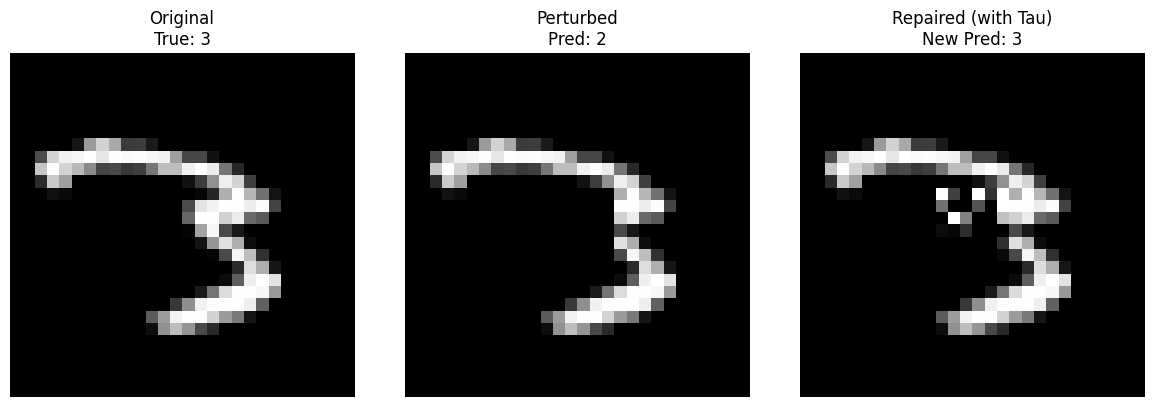


--- Case 2 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 603.5793 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 3 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 602.3957 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 4 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 603.7522 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 5 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.3326 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 6 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.8729 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 7 / 80 ---

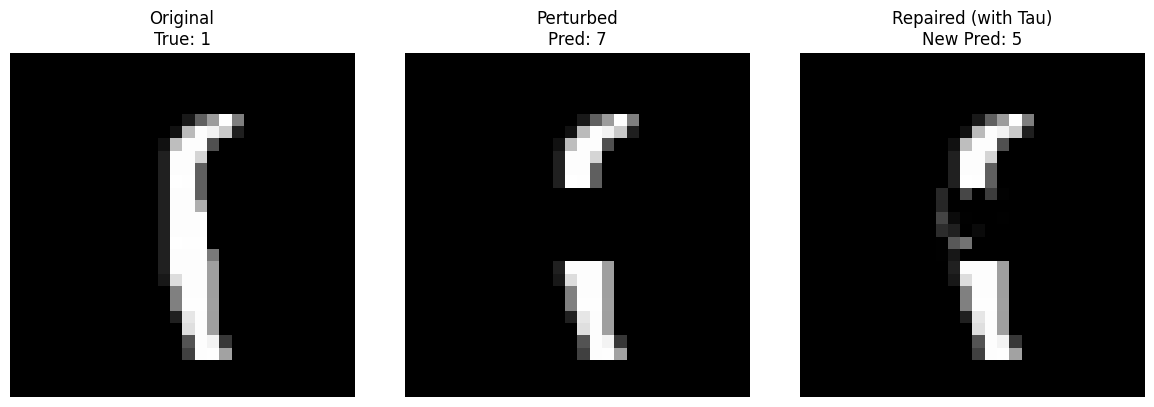


--- Case 9 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 17.382379198810124
Optimization Time: 65.5624 seconds
Successfully restored!


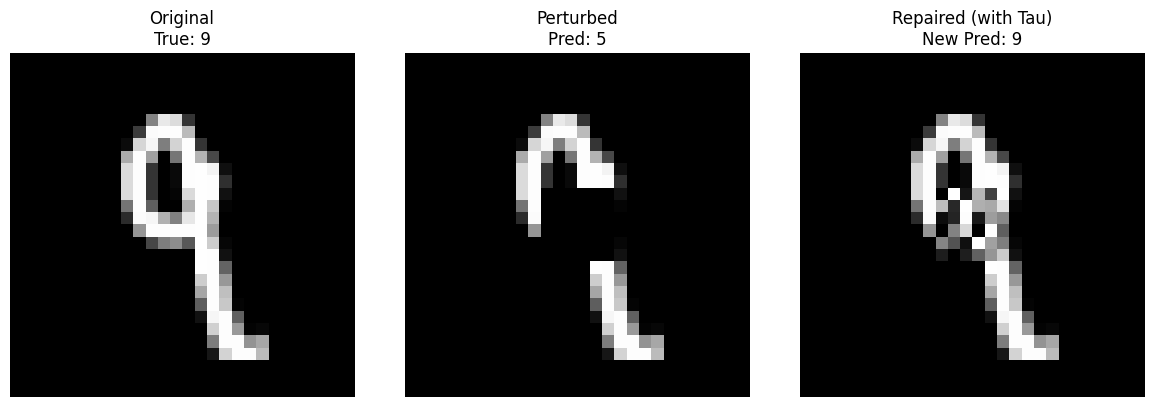


--- Case 10 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 601.3710 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 11 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.6813 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 12 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.4529 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 13 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.7434 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 14 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 605.5327 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 15 / 

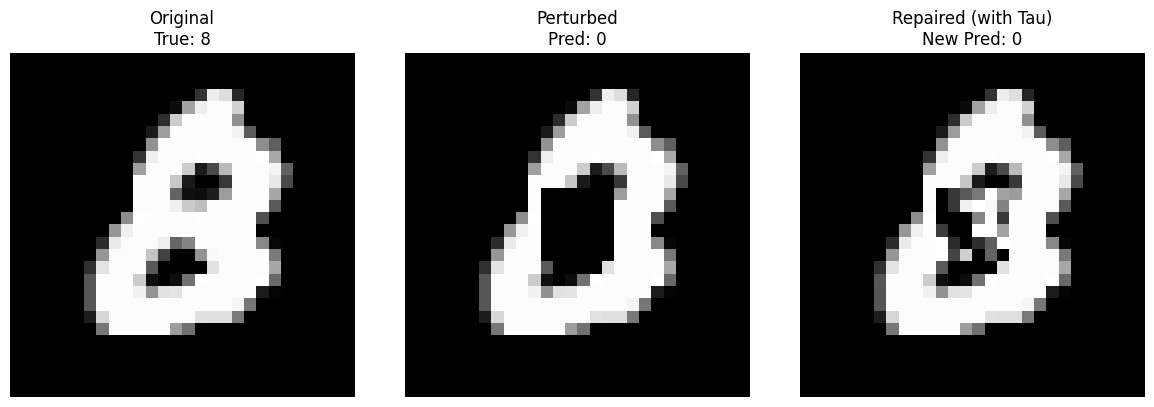


--- Case 20 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.7699 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 21 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
No Repair Found (Status 9)
Optimization Time: 603.0705 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 22 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 0.981987500323192
Optimization Time: 5.8127 seconds
Successfully restored!


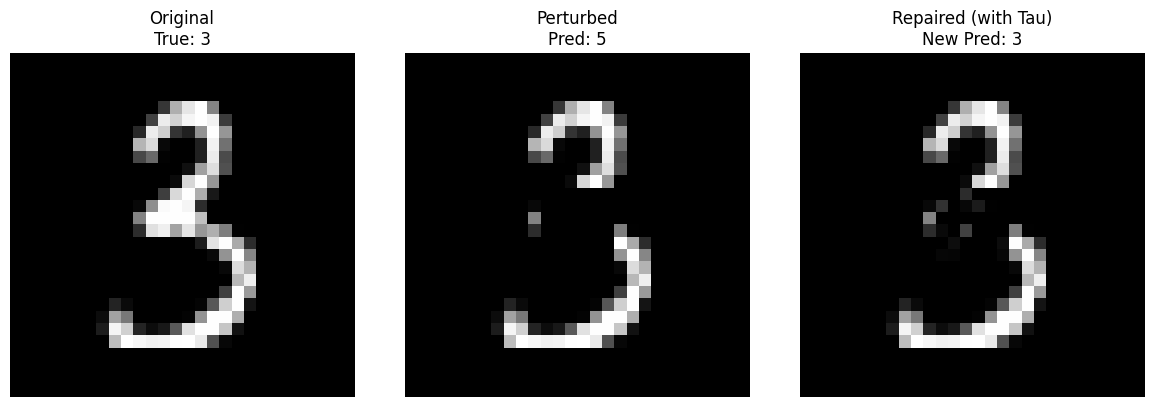


--- Case 23 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 0.46950784365536863
Optimization Time: 7.9123 seconds


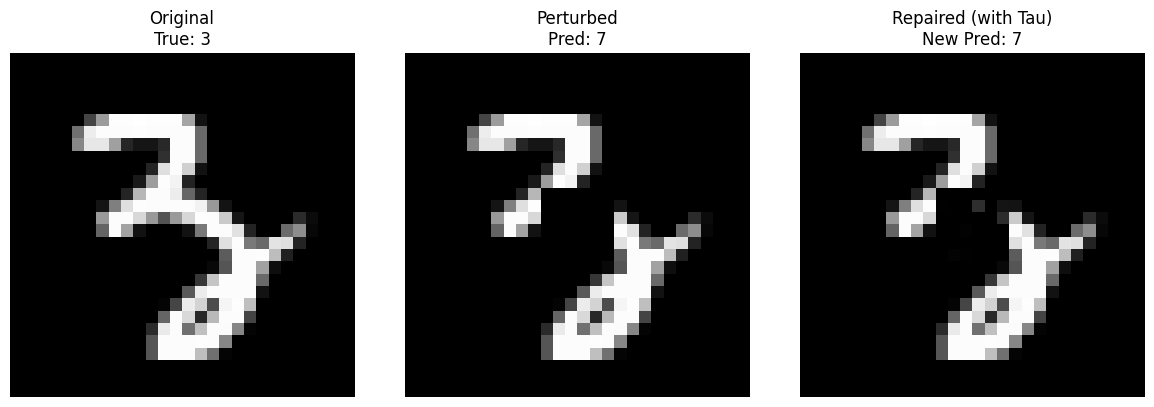


--- Case 24 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 1.1886178209859874
Optimization Time: 10.7755 seconds


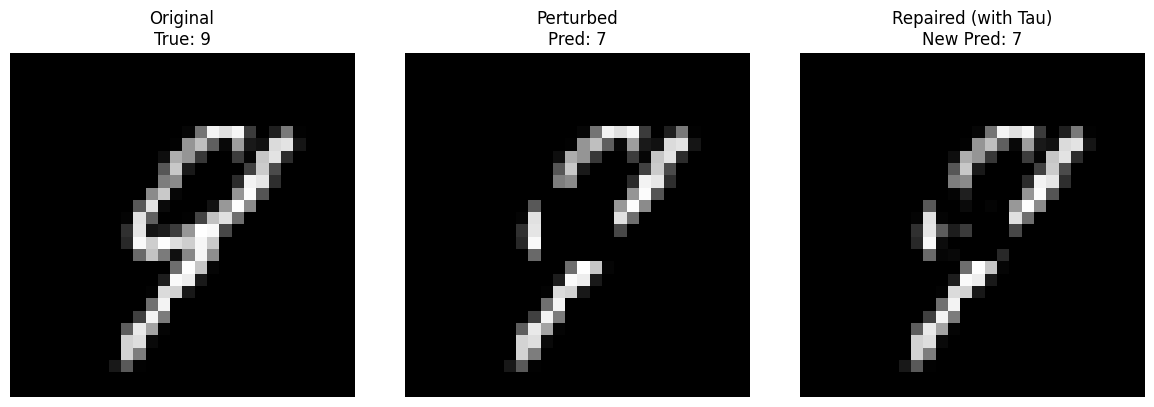


--- Case 25 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 603.9344 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 26 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
Pixels to add: 2.8698131107448943
Optimization Time: 8.8726 seconds
Successfully restored!


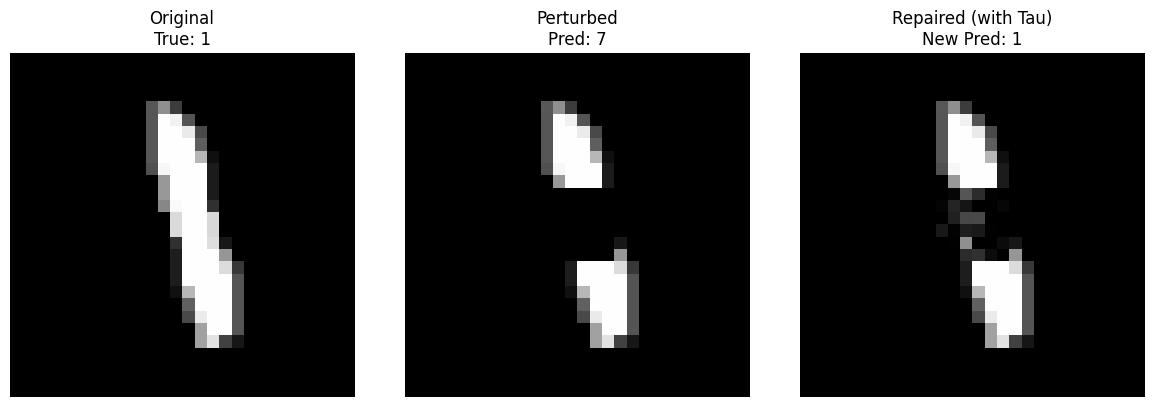


--- Case 27 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 3...
Pixels to add: 0.25805875969117664
Optimization Time: 4.5968 seconds


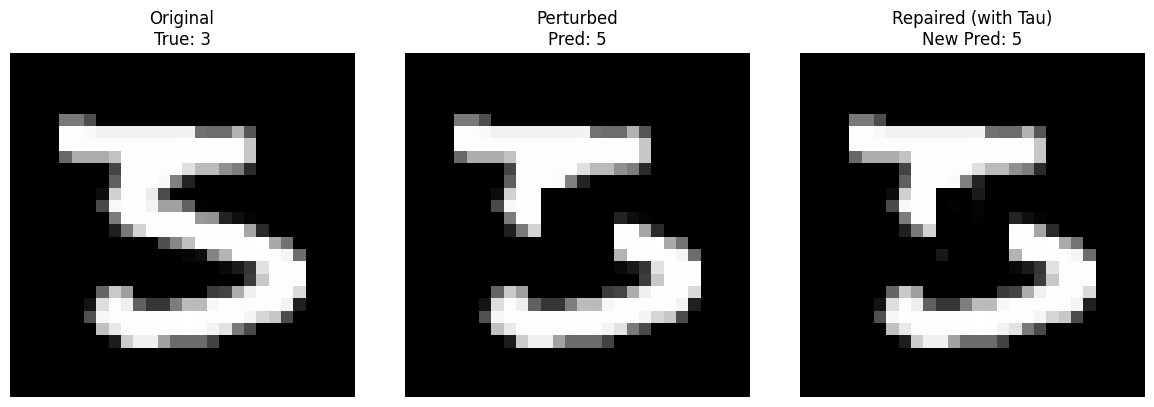


--- Case 28 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 602.9460 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 29 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 602.5692 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 30 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.6063 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 31 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.5319 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 32 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
Pixels to add: 6.844429094161826
Optimization Time: 10.1549 seconds
Successfully restored!


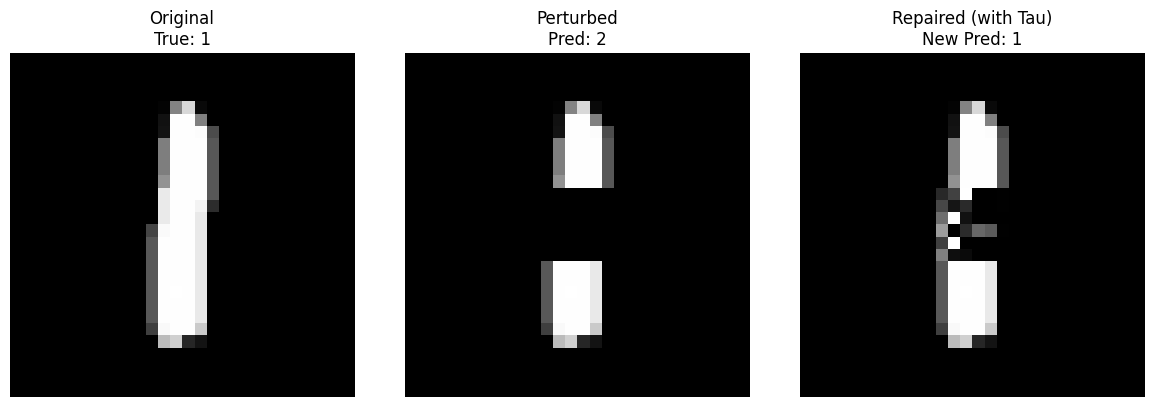


--- Case 33 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 602.3260 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 34 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 8...
No Repair Found (Status 9)
Optimization Time: 601.3699 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 35 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 601.0023 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 36 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.8169 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 37 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 602.6537 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 38 / 

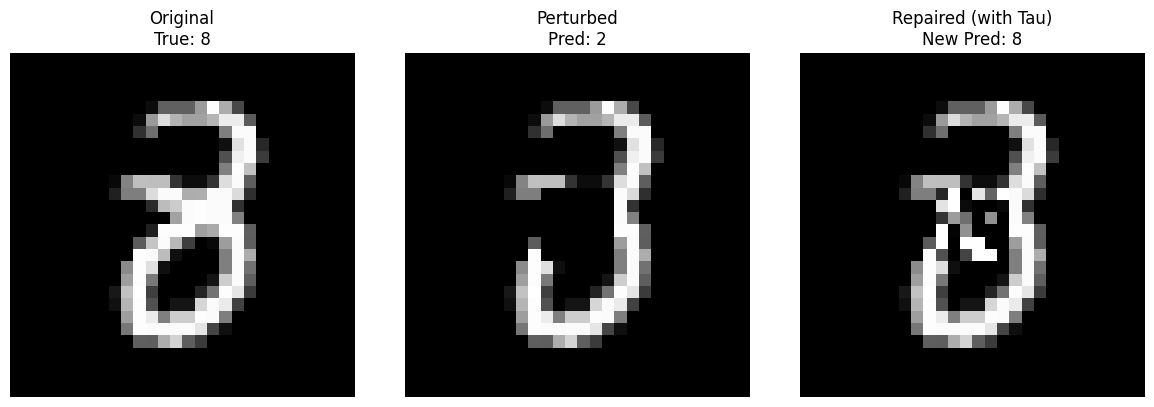


--- Case 40 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.3060 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 41 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.1262 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 42 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 601.3912 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 43 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.4343 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 44 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.2730 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 45 / 

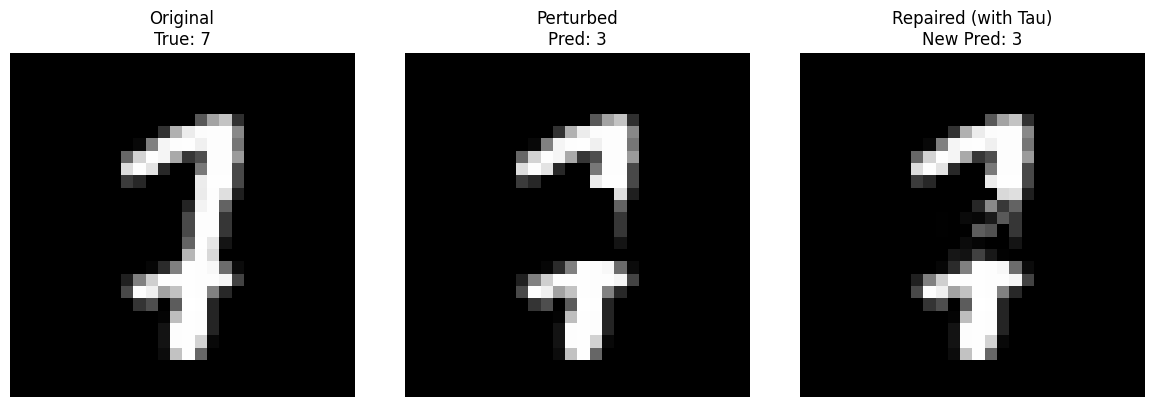


--- Case 55 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 18.641161578500153
Optimization Time: 42.3991 seconds
Successfully restored!


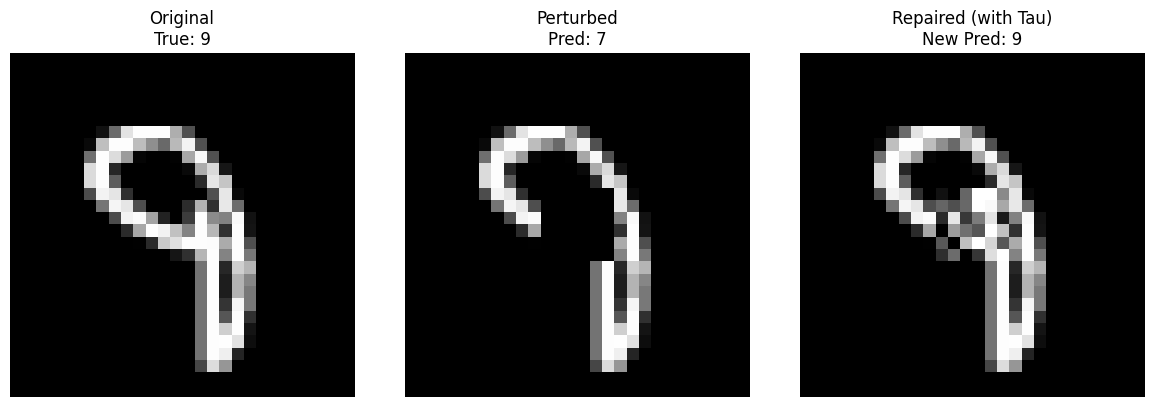


--- Case 56 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
No Repair Found (Status 9)
Optimization Time: 601.1451 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 57 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...
Pixels to add: 3.5407575526917503
Optimization Time: 3.1439 seconds


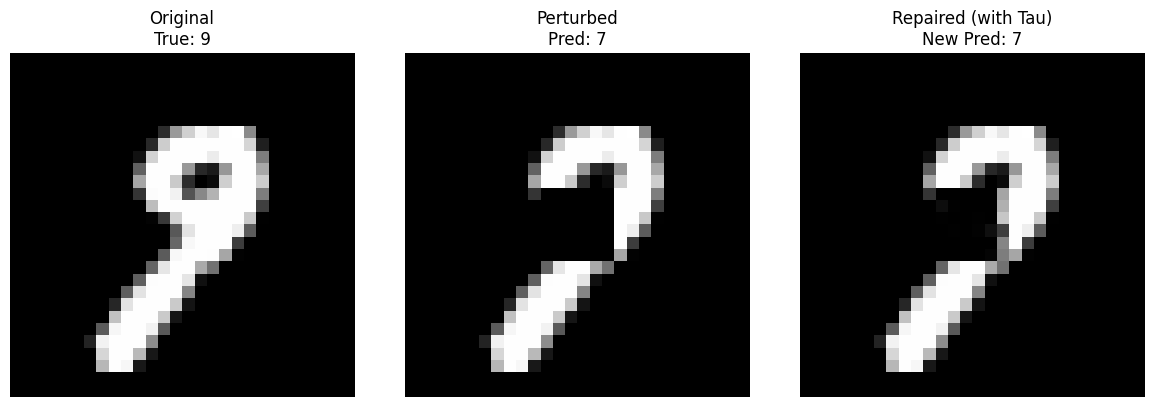


--- Case 58 / 80 ---
Set parameter TimeLimit to value 600
Solving for True Label 9...


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random  # <--- Added import

# 4. Solve & Visualize
subset = 100
grid_size = cutout_size
start_idx = 14 - grid_size // 2
correct = 0

# --- RANDOM SELECTION LOGIC ---
total_failures = len(failures)
actual_subset_size = min(subset, total_failures) # Safety check

if actual_subset_size < subset:
    print(f"Warning: Requested {subset} images, but only found {total_failures} failures.")

print(f"Selecting {actual_subset_size} random failure cases...")
selected_failures = random.sample(failures, actual_subset_size)
# ------------------------------

st_time = time.time()

# Iterate over the randomly selected list
for i, case in enumerate(selected_failures):
    print(f"\n--- Case {i+1} / {actual_subset_size} ---")

    # --- START TIMER ---
    start_time = time.time()

    # Run the solver
    tau_val = solve_tau_milp(model_cnn, case, grid_size=grid_size,tauType=1)

    # --- STOP TIMER ---
    elapsed_time = time.time() - start_time
    print(f"Optimization Time: {elapsed_time:.4f} seconds")

    if tau_val is not None:
        plt.figure(figsize=(12, 4))

        # 1. Original
        plt.subplot(1, 3, 1)
        plt.title(f"Original\nTrue: {np.argmax(case['true_label'])}")
        plt.imshow(case['original'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 2. Perturbed (Attack)
        plt.subplot(1, 3, 2)
        plt.title(f"Perturbed\nPred: {case['wrong_label']}")
        plt.imshow(case['perturbed'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 3. Apply Tau (Repair)
        repaired = case['perturbed'].copy()

        # Robust logic: Zero out the area first, then add tau
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] = 0.0
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] += tau_val

        # Verify Prediction
        pred_prob = model_cnn.predict(np.expand_dims(repaired, 0), verbose=0)
        pred_lbl = np.argmax(pred_prob)

        if(pred_lbl == np.argmax(case['true_label'])):
            correct += 1
            print(f"Successfully restored!")

        plt.subplot(1, 3, 3)
        plt.title(f"Repaired (with Tau)\nNew Pred: {pred_lbl}")
        plt.imshow(repaired, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(">> No solution found (Infeasible or Timed Out)")

el_time = time.time() - st_time

print(f"Total time taken to process {actual_subset_size} images : {el_time:.2f}s")
print(f"Success Rate: {correct}/{actual_subset_size} = {correct/actual_subset_size*100:.2f}%")